In [8]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

def permutation_importance_svm(
    X,
    y,
    n_splits=5,
    slice_size=25,
    max_slices=None,
    random_state=42,
):
    n_samples, n_features = X.shape
    skf = StratifiedKFold(
        n_splits=n_splits, shuffle=True, random_state=random_state
    )

    feature_importance = np.zeros(n_features)

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        print(f"\n===== Fold {fold}/{n_splits} =====")

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = SVC(kernel="rbf", class_weight="balanced")

        model.fit(X_train, y_train)

        # 在整个testfold上先预测一次，得到baseline预测
        y_pred_base = model.predict(X_test)

        fold_samples = X_test.shape[0]
        n_slices = fold_samples // slice_size
        if n_slices == 0:
            # 样本太少直接跳过
            continue

        if max_slices is not None:
            n_slices = min(n_slices, max_slices)

        print(f"  使用 slices 数量: {n_slices}")

        # 预先保存每个slice的baseline acc，避免重复算
        baseline_acc_slice = np.zeros(n_slices)
        slice_ranges = []

        for s in range(n_slices):
            start = s * slice_size
            end = start + slice_size
            idx = slice(start, end)
            slice_ranges.append(idx)

            y_slice = y_test[idx]
            y_pred_slice = y_pred_base[idx]
            baseline_acc_slice[s] = accuracy_score(y_slice, y_pred_slice)

        # 对每一个特征j做permutation
        for j in range(n_features):
            drop_sum = 0.0

            for s in range(n_slices):
                idx = slice_ranges[s]
                X_slice = X_test[idx].copy()
                y_slice = y_test[idx]

                # 在当前slice内随机打乱第j个特征
                shuffled = np.random.permutation(X_slice[:, j])
                X_slice[:, j] = shuffled

                # 只在这个slice上预测
                y_pred_perm = model.predict(X_slice)
                acc_perm = accuracy_score(y_slice, y_pred_perm)

                drop_sum += baseline_acc_slice[s] - acc_perm

            # 对slices取平均，得到该fold下特征j的重要性
            feature_importance[j] += drop_sum / n_slices

    # 对folds取平均
    feature_importance /= n_splits
    return feature_importance

In [9]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [10]:
beat_train = pd.read_csv("train_beats.csv", header=None)
X_beat = beat_train.iloc[:, :-1].values
y_beat = beat_train.iloc[:, -1].values.astype(int)

importance_beat = permutation_importance_svm(
    X_beat,
    y_beat,
    n_splits=5,
    slice_size=25,
    max_slices=60,
    random_state=42,
)

np.save("importance_beats.npy", importance_beat)


===== Fold 1/5 =====
  使用 slices 数量: 60

===== Fold 2/5 =====
  使用 slices 数量: 60

===== Fold 3/5 =====
  使用 slices 数量: 60

===== Fold 4/5 =====
  使用 slices 数量: 60

===== Fold 5/5 =====
  使用 slices 数量: 60


In [11]:
pat_train = pd.read_csv("train_patients.csv", header=None)
X_pat = pat_train.iloc[:, :-1].values
y_pat = pat_train.iloc[:, -1].values.astype(int)

importance_patient = permutation_importance_svm(
    X_pat,
    y_pat,
    n_splits=5,
    slice_size=25,
    max_slices=60,
    random_state=42,
)

np.save("importance_patients.npy", importance_patient)


===== Fold 1/5 =====
  使用 slices 数量: 60

===== Fold 2/5 =====
  使用 slices 数量: 60

===== Fold 3/5 =====
  使用 slices 数量: 60

===== Fold 4/5 =====
  使用 slices 数量: 60

===== Fold 5/5 =====
  使用 slices 数量: 60


Beat-holdout importance shape: (276,)
Patient-holdout importance shape: (276,)


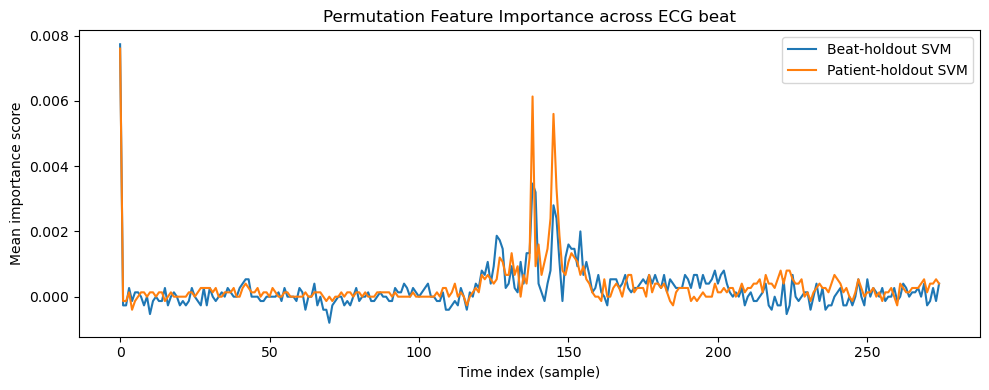

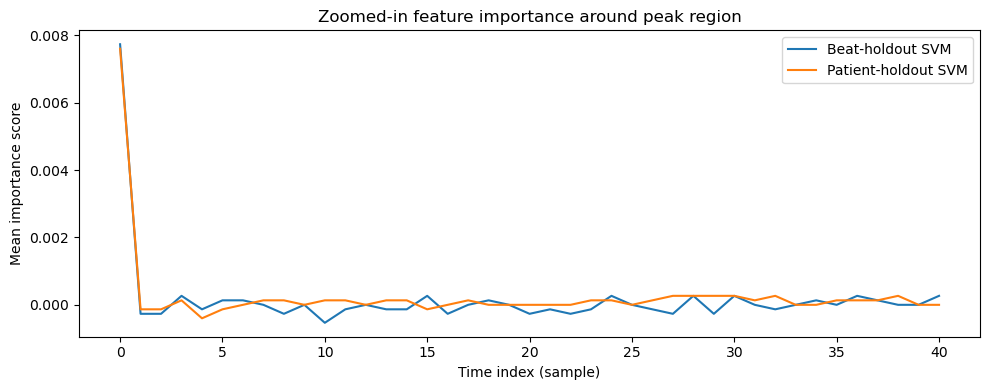

Peak index (beat-holdout): 0


In [16]:
import matplotlib.pyplot as plt

importance_beat = np.load("importance_beats.npy")
importance_patient = np.load("importance_patients.npy")

print("Beat-holdout importance shape:", importance_beat.shape)
print("Patient-holdout importance shape:", importance_patient.shape)

importance_beat = importance_beat[:275]
importance_patient  = importance_patient[:275]

x = np.arange(len(importance_beat))


plt.figure(figsize=(10, 4))
plt.plot(x, importance_beat, label="Beat-holdout SVM")
plt.plot(x, importance_patient, label="Patient-holdout SVM")

plt.title("Permutation Feature Importance across ECG beat")
plt.xlabel("Time index (sample)")
plt.ylabel("Mean importance score")
plt.legend()
plt.tight_layout()
plt.show()


# 以beat-holdout的最大重要性所在位置为中心，截一个窗口
peak_idx = int(np.argmax(importance_beat))
window = 40

start = max(0, peak_idx - window)
end = min(len(importance_beat), peak_idx + window + 1)

plt.figure(figsize=(10, 4))
plt.plot(x[start:end], importance_beat[start:end], label="Beat-holdout SVM")
plt.plot(x[start:end], importance_patient[start:end], label="Patient-holdout SVM")

plt.title("Zoomed-in feature importance around peak region")
plt.xlabel("Time index (sample)")
plt.ylabel("Mean importance score")
plt.legend()
plt.tight_layout()
plt.show()

print("Peak index (beat-holdout):", peak_idx)